# Introduction

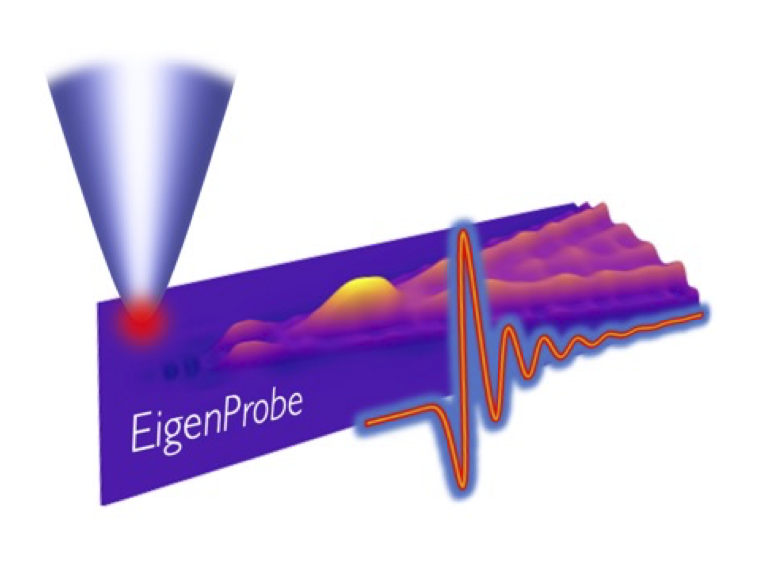

In [1]:
from IPython.display import Image
Image("../Documentation/EigenProbe_Logo.png",width=500)

# Imports

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import scipy
import warnings
import sys

import EigenProbe as EP
from EigenProbe import ProbeSpectroscopy as PS
sys.modules['ProbeCavityEigenfields'] = EP # This hook allows to continue to load probe files that were previously saved under an older alias for `EigenProbe`

from EigenProbe import common
sys.modules['common'] = common # This hook allows to continue to load probe files that were previously saved under an older alias for `common`

from EigenProbe.common.baseclasses import AWA
from EigenProbe.common import plotting
from EigenProbe import Materials as M
from EigenProbe.Materials import TransferMatrixMedia as TMM
from NearFieldOptics import TipModels as T
#warnings.simplefilter("ignore")

<plotting>:
	Registered colormaps "Warm" and "Warm_r"...
<plotting>:
	Registered colormaps "vanheum" and "vanheum_r"...
<plotting>:
	Registered colormaps "NT-MDT" and "NT-MDT_r"...
<plotting>:
<plotting>:
	Registered colormaps "jingdi" and "jingdi_r"...
<plotting>:
	Registered colormaps "Halcyon" and "Halcyon_r"...
<plotting>:
	Registered colormaps "Cold" and "Cold_r"...
<plotting>:
	Registered colormaps "Sky" and "Sky_r"...
<plotting>:
	Registered colormaps "Gwyddion.net" and "Gwyddion.net_r"...
<plotting>:
	Registered colormaps "BlueRed" and "BlueRed_r"...
<plotting>:
	Registered colormaps "vanheum3" and "vanheum3_r"...
<plotting>:
	Registered colormaps "vanheum2" and "vanheum2_r"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "Bi2Se3_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	<material_types.TabulatedMaterialFromFile.__init__>:
		Loading tabulated material data from file "PMMA_epsilon.pickle"...
<mater

# ArrayWithAxes (AWA)
AWAs are incredibly useful constructs if you're going to be intensively using EigenProbe. They are classes which allow the programmer to attach a set of axes to an array which make them very useful for representing functions. Below is a very simple example of using AWAs but, as the number of axes increases, so does the utility of using AWAs...

## Plotting
Say that I want to plot an array as a function of another array. Maybe I have 2 arrays which are both functions of a common array that I want to sum...

### Working without AWAs

Text(0.5, 1.0, 'Several 1-D `AWA` instances, plotted')

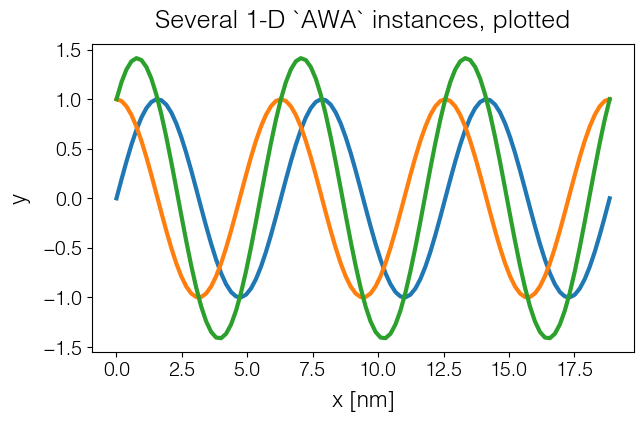

In [3]:
x = np.linspace(0,6*np.pi,100)
y1 = np.sin(x)
y2 = np.cos(x)
y_sum = y1+y2

plt.figure(figsize=(7,4))
plt.plot(x,y1)
plt.plot(x,y2)
plt.plot(x,y_sum)
plt.xlabel("x [nm]")
plt.ylabel("y");
plt.title('Several 1-D `AWA` instances, plotted')

### Working with AWAs

Text(0.5, 1.0, 'Several 1-D `AWA` instances, plotted')

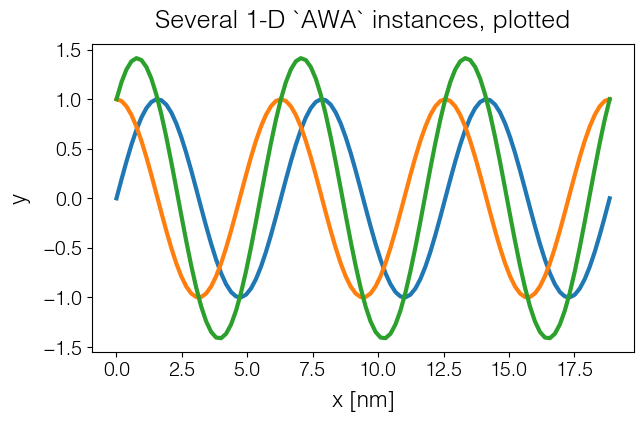

In [4]:
x = np.linspace(0,6*np.pi,100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.figure(figsize=(7,4))
y1_AWA = AWA(y1, axes=[x], axis_names=["x [nm]"])
y2_AWA = AWA(y2, axes=[x], axis_names=["x [nm]"])

y1_AWA.plot()
y2_AWA.plot()
(y1_AWA+y2_AWA).plot()
plt.ylabel("y");
plt.title('Several 1-D `AWA` instances, plotted')

## Value extraction
Let's say I have an array y = sin(x) which is a function of array x and I would like to know what is the value of y at the point x=0.83728. Chances are slim that this specific value happens to be in my x array so there is an unnecessarily involved procedure to figure this out without AWAs.

### Working without AWAs

In [5]:
x = np.linspace(0,6*np.pi,100)
y = np.sin(x)
my_x = 0.83728
closest_idx = np.argmin(np.abs(x-my_x))
my_y = y[closest_idx]
print("Value at {}: {}".format(my_x, my_y))

Value at 0.83728: 0.6900790114821119


### Working with AWAs

In [6]:
x = np.linspace(0,6*np.pi,100)
y = np.sin(x)
y_AWA = AWA(y,axes=[x],axis_names=["x [nm]"])
my_x = 0.83728
my_y = y_AWA.cslice[my_x]
print("Value at {}: {}".format(my_x, my_y))

Value at 0.83728: 0.6900790114821119


Text(0.5, 1.0, 'Interpolating an `AWA` instance')

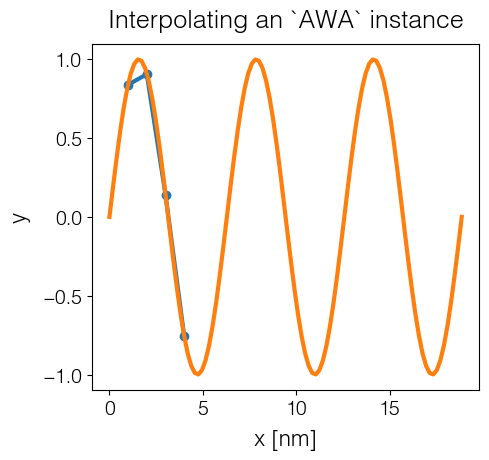

In [7]:
y_AWA.interpolate_axis([1,2,3,4],axis=0).plot(marker='o')
y_AWA.plot()
plt.ylabel("y");
plt.title('Interpolating an `AWA` instance')

# Creating Materials

## Get a list of materials available from `EigenProbe.Materials`

In [8]:
print("Materials readily available from EigenProbe.Materials:")
for name,val in vars(M).items():
    if isinstance(val,M.Material):
        print("\tM.{}".format(name))

Materials readily available from EigenProbe.Materials:
	M.Air
	M.Al2O3
	M.Al2O3_2
	M.Au
	M.Bi2Se3_Bulk
	M.BN_GPR
	M.BN_STW
	M.BN_Caldwell
	M.Forsterite
	M.FePO4
	M.FePO4_2
	M.LiFePO4
	M.LiFePO4_calc
	M.PMMA
	M.PZT
	M.Si
	M.Si_Doped
	M.SiO2
	M.SiC_4H
	M.SiC_4H_2
	M.SiC_4H_Dispersive
	M.SiC_6H
	M.SiC_6H_2
	M.SiC_6H_Ellips
	M.SiC_3C
	M.SiN4_Bulk
	M.SiO2_Fei
	M.SiO2_300nmFei
	M.SiO2_Bulk
	M.SiO2_300nm
	M.SiO2_300nm2
	M.SiO2_300nm2_test
	M.SiO2_144nm
	M.STO
	M.TaS2_NCCDW
	M.TaS2_metal
	M.TaS2_CCDW
	M.TiO2
	M.BSTS_35nm_Bulk
	M.VO2_Insulating
	M.VO2_Metallic
	M.V2O3_Insulating
	M.V2O3_Metallic


In [9]:
M.VO2_Insulating.reflection_p(1000,q=1/(10e-7))

(0.6704222913546831+0.002864716875637605j)

## Isotropic materials

In [10]:
# Grab the built-in instance of silicon oxide from EigenProbe.Materials:
sio2 = M.SiO2_300nm

Text(0.5, 1.0, 'SiO$_2$: optical permittivity')

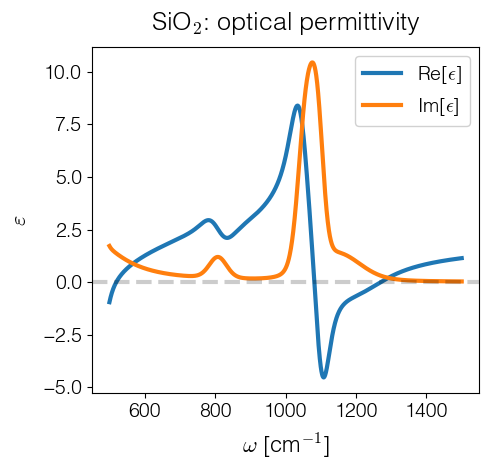

In [11]:
ws = np.linspace(500,1500,1500)
eps = sio2.epsilon(ws)
eps = AWA(eps,axes=[ws],axis_names=[r"$\omega$ [cm$^{-1}$]"])
eps.real.plot(label=r"Re[$\epsilon$]")
eps.imag.plot(label=r"Im[$\epsilon$]")
plt.ylabel(r'$\varepsilon$')
plt.legend()
plt.axhline(0,ls='--',color='k',alpha=.2)
plt.title(r'SiO$_2$: optical permittivity')

## Gold

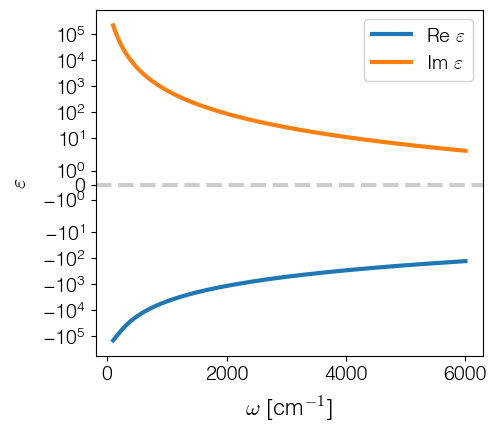

In [12]:
freqs=np.linspace(100,6000,1000)
eps=M.Au.epsilon(freqs)
eps = AWA(eps,axes=[freqs],axis_names=[r"$\omega$ [cm$^{-1}$]"])
eps.real.plot(label=r'Re $\varepsilon$')
eps.imag.plot(label=r'Im $\varepsilon$')
plt.gca().set_yscale('symlog')
plt.ylabel(r'$\varepsilon$')
plt.legend()
plt.axhline(0,ls='--',color='k',alpha=.2)


In [13]:
M.Au.eps_infinity # Background (high-energy) permittivity is generally positive

1

In [14]:
M.Au.drude_params # Drude parameters are a tuple of (plasma frequency, scattering rate), both in wavenumbers.

[69000.0, 148.4]

## VO2

Text(0.5, 1.0, 'Metallic VO$_2$: optical permittivity')

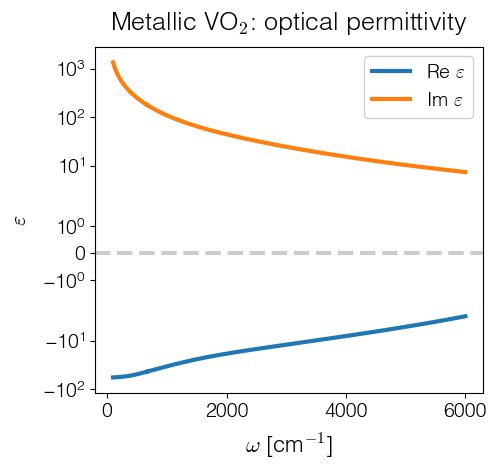

In [15]:
freqs=np.linspace(100,6000,1000)
eps=M.VO2_Metallic.epsilon(freqs)
eps = AWA(eps,axes=[freqs],axis_names=[r"$\omega$ [cm$^{-1}$]"])
eps.real.plot(label=r'Re $\varepsilon$')
eps.imag.plot(label=r'Im $\varepsilon$')
plt.gca().set_yscale('symlog')
plt.ylabel(r'$\varepsilon$')
plt.legend()
plt.axhline(0,ls='--',color='k',alpha=.2)

plt.title(r'Metallic VO$_2$: optical permittivity')

Text(0.5, 1.0, 'Insulating VO$_2$: optical permittivity')

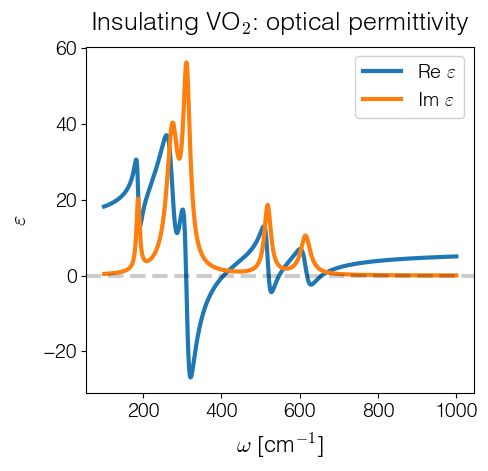

In [16]:
freqs=np.linspace(100,1000,1000)
eps=M.VO2_Insulating.epsilon(freqs)
eps = AWA(eps,axes=[freqs],axis_names=[r"$\omega$ [cm$^{-1}$]"])
eps.real.plot(label=r'Re $\varepsilon$')
eps.imag.plot(label=r'Im $\varepsilon$')
#plt.gca().set_yscale('symlog')
#plt.ylim(-10,10)
plt.ylabel(r'$\varepsilon$')
plt.legend()
plt.axhline(0,ls='--',color='k',alpha=.2)

plt.title(r'Insulating VO$_2$: optical permittivity')

Text(0.5, 1.0, 'Insulating VO$_2$: far-field reflectivity ($p$)')

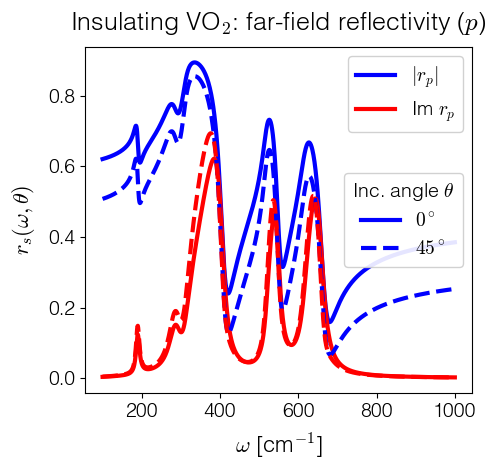

In [17]:
rp = M.VO2_Insulating.reflection_p(freqs,angle=0)
rp.set_axes(rp.axes,axis_names=[r"$\omega$ [cm$^{-1}$]"])
l1,=np.abs(rp).plot(color='b',label=r'$|r_p|$')
np.imag(rp).plot(color='r',label=r'Im $r_p$')

rp = M.VO2_Insulating.reflection_p(freqs,angle=45)
rp.set_axes(rp.axes,axis_names=[r"$\omega$ [cm$^{-1}$]"])
l2,=np.abs(rp).plot(color='b',ls='--')
np.imag(rp).plot(color='r',ls='--')

leg1 = plt.legend(loc='upper right')

# 4. Use add_artist to prevent the first legend from being removed
plt.gca().add_artist(leg1)

# 5. Create and display the second legend in a different location
plt.legend(handles=(l1,l2),labels=[r'$0^\circ$',r'$45^\circ$'],loc='center right',title=r'Inc. angle $\theta$')
plt.ylabel(r'$r_s(\omega,\theta)$')

plt.title(r'Insulating VO$_2$: far-field reflectivity ($p$)')

Note that the p- and s-polarized reflection coefficients differ only by a factor of -1 for normal incidence, owing only to a difference in their definition of the field direction (Novotny Ch. 1)

Text(0.5, 1.0, 'Insulating VO$_2$: far-field reflectivity ($s$)')

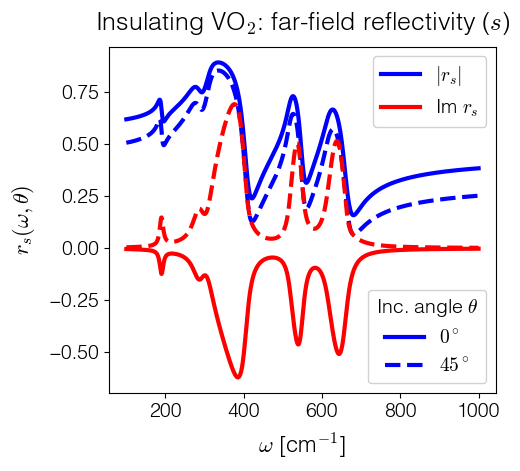

In [18]:
rs = M.VO2_Insulating.reflection_s(freqs,angle=0)
rs.set_axes(rs.axes,axis_names=[r"$\omega$ [cm$^{-1}$]"])
l1,=np.abs(rs).plot(color='b',label=r'$|r_s|$')
np.imag(rs).plot(color='r',label=r'Im $r_s$')

rs = M.VO2_Insulating.reflection_p(freqs,angle=45)
rs.set_axes(rs.axes,axis_names=[r"$\omega$ [cm$^{-1}$]"])
l2,=np.abs(rs).plot(color='b',ls='--')
np.imag(rs).plot(color='r',ls='--')

leg1 = plt.legend(loc='upper right')

# 4. Use add_artist to prevent the first legend from being removed
plt.gca().add_artist(leg1)

# 5. Create and display the second legend in a different location
plt.legend(handles=(l1,l2),labels=[r'$0^\circ$',r'$45^\circ$'],loc='lower right',title=r'Inc. angle $\theta$')

plt.ylabel(r'$r_s(\omega,\theta)$')
plt.title(r'Insulating VO$_2$: far-field reflectivity ($s$)')

## Anisotropic materials

In [19]:
# Grab the built-in instance of SiC4H from EigenProbe.Materials:
SiC_4H = M.SiC_4H

In [20]:
SiC_4H.eps_lps # Oscillator parameters come in trios; we have one oscillator per each of (a,b,c) axes.

[[(2022247.5263999996, 796.6, 5.3584)],
 [(2022247.5263999996, 796.6, 5.3584)],
 [(2167572.7800000003, 782.0, 5.3584)]]

Text(0.5, 1.0, 'SiC-4H: Anisotropic permittivity')

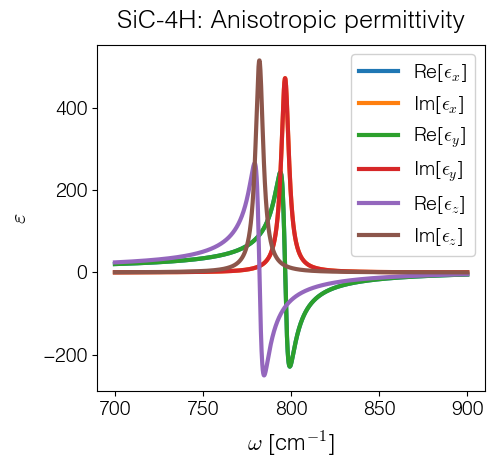

In [21]:
ws = np.linspace(700,900,1500)
eps_x = AWA([eps[0,0] for eps in SiC_4H.epsilon_anisotropic(ws)],axes=[ws],axis_names=[r"$\omega$ [cm$^{-1}$]"])
eps_y = AWA([eps[1,1] for eps in SiC_4H.epsilon_anisotropic(ws)],axes=[ws],axis_names=[r"$\omega$ [cm$^{-1}$]"])
eps_z = AWA([eps[2,2] for eps in SiC_4H.epsilon_anisotropic(ws)],axes=[ws],axis_names=[r"$\omega$ [cm$^{-1}$]"])

eps_x.real.plot(label=r"Re[$\epsilon_x$]")
eps_x.imag.plot(label=r"Im[$\epsilon_x$]")
eps_y.real.plot(label=r"Re[$\epsilon_y$]")
eps_y.imag.plot(label=r"Im[$\epsilon_y$]")
eps_z.real.plot(label=r"Re[$\epsilon_z$]")
eps_z.imag.plot(label=r"Im[$\epsilon_z$]")
plt.ylabel(r'$\varepsilon$')

plt.legend();
plt.title('SiC-4H: Anisotropic permittivity')

In [22]:
# Grab the built-in instance of sapphire from EigenProbe.Materials:
sapphire = M.Al2O3

Text(0, 0.5, '$\\varepsilon$')

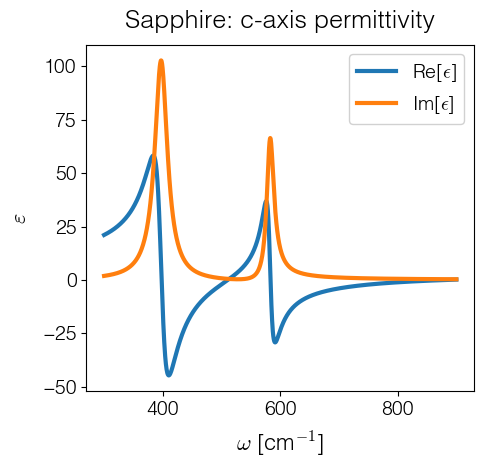

In [23]:
ws = np.linspace(300,900,1500)
eps = AWA(sapphire.extraordinary_epsilon(ws),axes=[ws],axis_names=[r"$\omega$ [cm$^{-1}$]"])
eps.real.plot(label=r"Re[$\epsilon$]")
eps.imag.plot(label=r"Im[$\epsilon$]")
plt.legend();
plt.title('Sapphire: c-axis permittivity')
plt.ylabel(r'$\varepsilon$')

In [24]:
# These phonon parameters can be manipulated, but follow the form:
# `[eps_ab, eps_ab, eps_c]`
# where for example:
# `eps_ab = [phonon1, phonon2, phonon3, ...]`
# and where for example each phonon is specified by:
# `phonon1 = [LO frequency, LO linewidth, TO frequency, TO linewidth]`
sapphire.phonon_params

[[(387.6, 15.5, 385, 16.5),
  (481.68, 9.5, 439.1, 15.5),
  (629.5, 29.5, 569, 23.5),
  (906.6, 73.5, 633.63, 25)],
 [(387.6, 15.5, 385, 16.5),
  (481.68, 9.5, 439.1, 15.5),
  (629.5, 29.5, 569, 23.5),
  (906.6, 73.5, 633.63, 25)],
 [(510.87, 5.5, 397.52, 26.5), (881.1, 77.0, 582.41, 15)]]

## Graphene

Text(0.5, 1.0, 'Single Layer Graphene: optical conductivity')

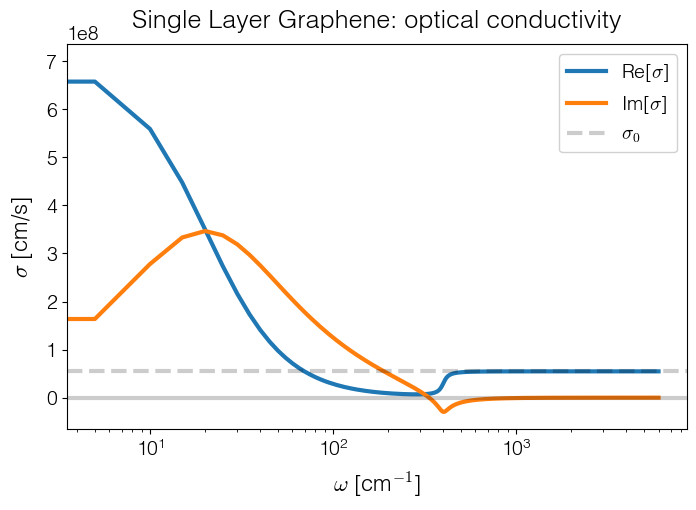

In [25]:
# Instantiate an instance of single layer graphene with:
#    Fermi level = 2400 1/cm = 297.6 meV
#    gamma = 20 1/cm
Graphene = M.SingleLayerGraphene(chemical_potential=200, gamma=20)

ws = np.linspace(0,6000,1200)
qs = np.linspace(1e3, 1e6, 100)
sigma = AWA(Graphene.conductivity(ws),axes=[ws],axis_names=[r"$\omega$ [cm$^{-1}$]"])

plt.figure(figsize=(8,5))
sigma.real.plot(label=r"Re[$\sigma$]")
sigma.imag.plot(label=r"Im[$\sigma$]")
    
plt.axhline(Graphene.sigma0,color='k',ls='--',alpha=.2,label=r'$\sigma_0$')
plt.axhline(0,ls='-',color='k',alpha=.2)

plt.legend()
plt.ylabel(r"$\sigma$ [cm/s]");
plt.xscale("log")
plt.title('Single Layer Graphene: optical conductivity')

### Effect of chemical potential

Text(0.5, 1.0, 'Single Layer Graphene: optical conductivity versus Fermi level')

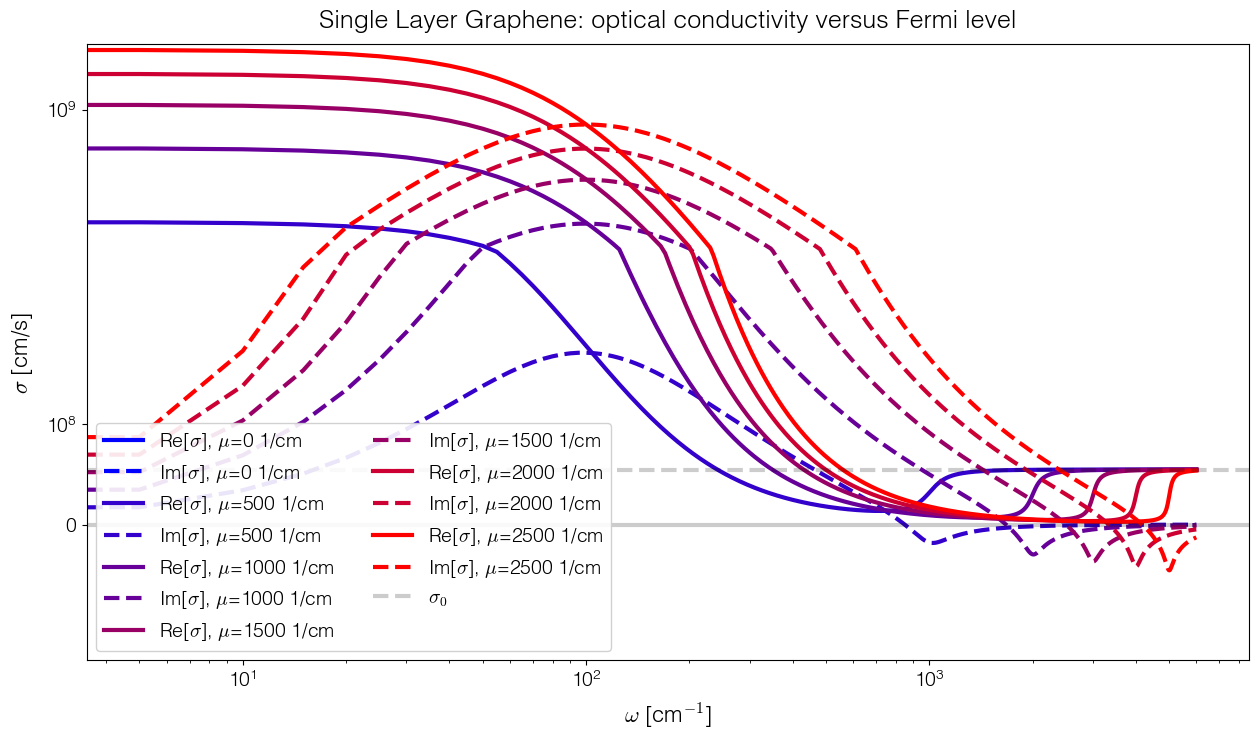

In [26]:
ws = np.linspace(0,6000,1200)
plt.figure(figsize=(15,8))
mus = np.arange(0,3000,500)
colors=plotting.bluered_colors(len(mus))
for mu in mus:
    Graphene = M.SingleLayerGraphene(chemical_potential=mu, gamma=100)
    c=next(colors)
    sigma = AWA(Graphene.conductivity(ws),axes=[ws],axis_names=[r"$\omega$ [cm$^{-1}$]"])
    sigma.real.plot(label=r"Re[$\sigma$], $\mu$={} 1/cm".format(mu),color=c)
    sigma.imag.plot(label=r"Im[$\sigma$], $\mu$={} 1/cm".format(mu),color=c,ls='--')
    
plt.axhline(Graphene.sigma0,color='k',ls='--',alpha=.2,label=r'$\sigma_0$')
plt.axhline(0,ls='-',color='k',alpha=.2)

plt.legend(ncol=2)
plt.ylabel(r"$\sigma$ [cm/s]");
plt.xscale("log")
plt.yscale("symlog",linthresh=5*Graphene.sigma0)
plt.title('Single Layer Graphene: optical conductivity versus Fermi level')

## hBN

In [27]:
# Grab the built-in instance of hBN from EigenProbe.Materials:
hBN = M.BN_Caldwell

Text(0.5, 1.0, 'hexagonal Boron Nitride (hBN): Anisotropic permittivity')

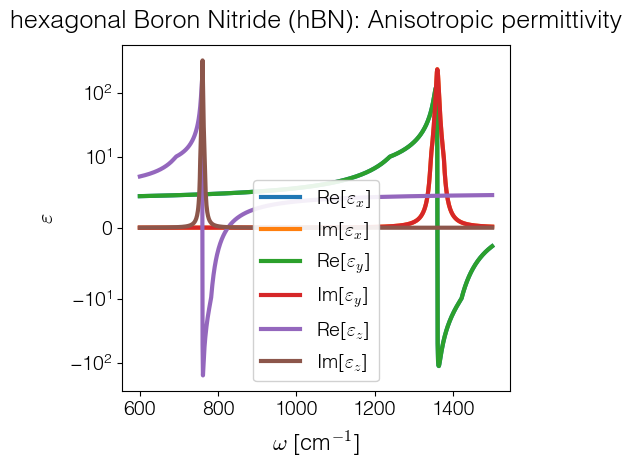

In [28]:
ws = np.linspace(600,1500,900)
eps = hBN.epsilon_anisotropic(ws)

eps_x = AWA([e[0,0] for e in eps], axes=[ws], axis_names=[r"$\omega$ [cm$^{-1}$]"])
eps_y = AWA([e[1,1] for e in eps], axes=[ws], axis_names=[r"$\omega$ [cm$^{-1}$]"])
eps_z = AWA([e[2,2] for e in eps], axes=[ws], axis_names=[r"$\omega$ [cm$^{-1}$]"])

eps_x.real.plot(label=r"Re[$\varepsilon_x$]")
eps_x.imag.plot(label=r"Im[$\varepsilon_x$]")
eps_y.real.plot(label=r"Re[$\varepsilon_y$]")
eps_y.imag.plot(label=r"Im[$\varepsilon_y$]")
eps_z.real.plot(label=r"Re[$\varepsilon_z$]")
eps_z.imag.plot(label=r"Im[$\varepsilon_z$]")

plt.ylabel(r"$\varepsilon$")
plt.legend(loc='lower center');
plt.gca().set_yscale('symlog',linthresh=10)

plt.title('hexagonal Boron Nitride (hBN): Anisotropic permittivity')

## Tabulated materials
If you have the optical constants for a material which is not included in the `EigenProbe.Materials` package, it is straightforward to create a Material instance of your custom material.

### Isotropic (example: WS$_2$)
Please see "EigenProbe/Materials/Tabulated/WS2.csv" for example of isotropic optical constant file.

In [29]:
WS2 = M.TabulatedMaterialFromFile("WS2.csv")

<material_types.TabulatedMaterialFromFile.__init__>:
	<material_types.TabulatedMaterialFromFile.__init__>:
		Loading tabulated material data from file "WS2.csv"...


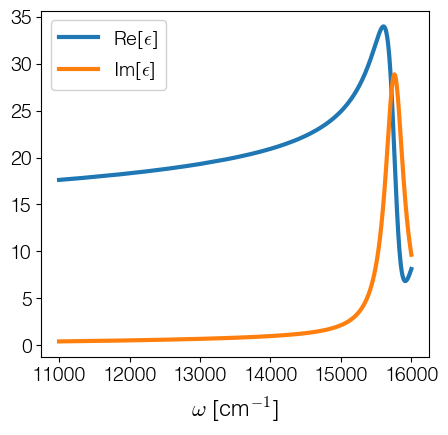

In [30]:
ws = np.linspace(11000,16000,5000)
eps = AWA(WS2.epsilon(ws),axes=[ws],axis_names=[r"$\omega$ [cm$^{-1}$]"])
eps.real.plot(label=r"Re[$\epsilon$]")
eps.imag.plot(label=r"Im[$\epsilon$]")
plt.legend();

### Anisotropic (example: BN)
Please see "EigenProbe/Materials/Tabulated/BN_anis.csv" for an example of formatting for an anisotropic optical constant file.

In [31]:
BN = M.TabulatedAnisotropicMaterialFromFile("BN_anis.csv")

<material_types.TabulatedAnisotropicMaterialFromFile.__init__>:
	<material_types.TabulatedAnisotropicMaterialFromFile.__init__>:
		Loading tabulated material data from file "/Users/alexandersmcleod/tools/python/EigenProbe/Materials/Tabulated/BN_anis.csv"...


Text(0.5, 1.0, 'hexagonal Boron Nitride (hBN): Anisotropic permittivity')

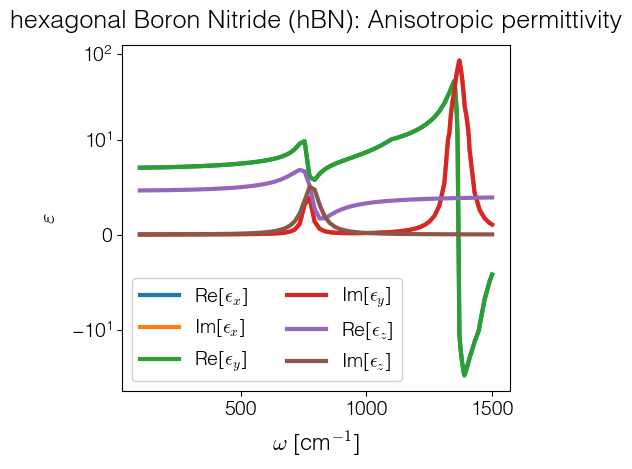

In [32]:
ws = np.linspace(100,1500,1400)
eps_x = AWA(BN.ordinary_epsilon(ws), axes=[ws], axis_names=[r"$\omega$ [cm$^{-1}$]"])
eps_y = AWA(BN.ordinary_epsilon(ws), axes=[ws], axis_names=[r"$\omega$ [cm$^{-1}$]"])
eps_z = AWA(BN.extraordinary_epsilon(ws), axes=[ws], axis_names=[r"$\omega$ [cm$^{-1}$]"])

eps_x.real.plot(label=r"Re[$\epsilon_x$]")
eps_x.imag.plot(label=r"Im[$\epsilon_x$]")
eps_y.real.plot(label=r"Re[$\epsilon_y$]")
eps_y.imag.plot(label=r"Im[$\epsilon_y$]")
eps_z.real.plot(label=r"Re[$\epsilon_z$]")
eps_z.imag.plot(label=r"Im[$\epsilon_z$]")
plt.ylabel(r'$\varepsilon$')

plt.legend(ncol=2);

plt.gca().set_yscale('symlog',linthresh=10)

plt.title('hexagonal Boron Nitride (hBN): Anisotropic permittivity')

# Layered structures
In this example, we will recreate the structure from Siyuan Dai's 2015 Nature paper "Graphene on hexagonal boron nitride as a tunable hyperbolic metamaterial" (https://www.nature.com/articles/nnano.2015.131).

As such, we will create a layered structure with: <br>
    ---------- Graphene ----------- <br>
    ---------- 58 nm hBN ---------- <br> 
    --------- 300 nm SiO2 --------- <br>
    ------------- Si --------------       

## Gather our materials

In [33]:
# Graphene with:
#    - Reasonable room temperature gamma = 20 1/cm
#    - Chemical potential = 370 meV = 2984.25 1/cm
Graphene = M.SingleLayerGraphene(chemical_potential=2984.25, gamma=20)
BN = M.BN_Caldwell
Si = M.Si
SiO2 = M.SiO2_300nm

## Create a `LayeredMediaTM` object

In [34]:
Layers = [
    Graphene,
    (BN,   58e-7),
    (SiO2, 300e-7)
]
Heterostructure = M.LayeredMediaTM(*Layers, exit = Si, entrance=M.Air)

In [35]:
Heterostructure.reflection_p(1000,q=1/(10e-7))

array([1.25202589+0.00946226j])

## Calculate $r_p(\omega,q)$

In [36]:
ws = np.linspace(600,1800,1200)
q0=1/10e-7
qs = np.linspace(1e-3*q0, 1*q0, 500)
rp = Heterostructure.reflection_p(ws,qs)
axis_names = [r"$\omega$  (cm$^{-1}$)", r'$q$  (cm$^{-1}$)']
rp.set_axes(axis_names=axis_names)

### Comparison to data

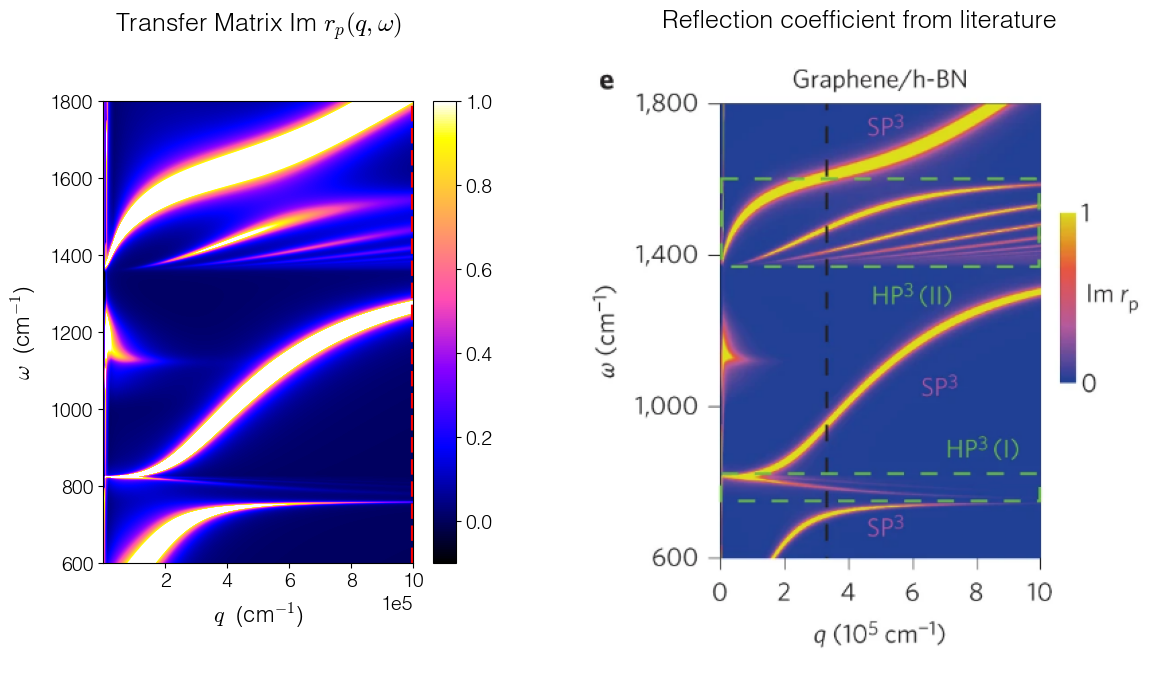

In [37]:
fig,ax = plt.subplots(figsize=(11,6),nrows=1,ncols=2)

plt.sca(ax[0])
rp.imag.T.plot(vmin=-.1,vmax=1,cmap='gnuplot2',colorbar=True)
plt.gca().ticklabel_format(axis="x", style="sci", scilimits=[5,5])
plt.axvline(q0,color='r',ls='--')
plt.title(r'Transfer Matrix Im $r_p(q,\omega)$',pad=50)

# Get current bounding box dimensions
box = ax[0].get_position()

# Shrink the width by 20% (multiplied by 0.8)
# Arguments: [left, bottom, width, height]
ax[0].set_position([box.x0, box.y0, box.width * 1, box.height*1])

plt.sca(ax[1])
plt.imshow(mpimg.imread("Example Data/S_Dai_rp.png"))
plt.gca().set_axis_off()
plt.title(r'Reflection coefficient from literature')

# Get current bounding box dimensions
box = ax[1].get_position()
# Shrink the width by 20% (multiplied by 0.8)
# Arguments: [left, bottom, width, height]
ax[1].set_position([box.x0, box.y0-.23, box.width * 1.5, box.height*1.5])

#plt.subplots_adjust(top = 1, bottom = 0, right = 1, left = 0, 
#            hspace = 0, wspace = 0)
plt.margins(0,0)
plt.gca().xaxis.set_major_locator(plt.NullLocator())
plt.gca().yaxis.set_major_locator(plt.NullLocator())

## Simulate s-SNOM nano-spectroscopy:  Calculate demodulated scattering over our layered material

In [38]:
probe_name = 'Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244'
EE = EP.load(probe_name, PS.EncodedEigenfields, overwrite_probe=True)

a_nm = 20 # Physical dimension of probe radius, in nanometers
A_nm = 80 # Tapping amplitude, in nanometers
gapmin_nm = a_nm/10 # Physical dimension of minimum probe-sample distance, in nanometers
Ngaps = 12 # Number of probe-sample gap nodesto use for computing demodulated scattering
Nmodes=15 # Number of eigenmodes used for the prediction.

sim_kwargs = dict(amplitude_nm=A_nm,gapmin_nm = gapmin_nm,a_nm=a_nm,Ngaps=Ngaps,Nmodes=Nmodes)

freqs_wn=np.linspace(600,1800,100) # Energies at which all spectra will be measured
norm_to = M.Au # Normalize to gold

S = EE.getNormalizedSignal(freqs_wn,
                           rp=Heterostructure.reflection_p,
                           rp_norm = norm_to.reflection_p,
                           norm_single_freq=True,
                           **sim_kwargs)

Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_EncodedEigenfields.pickle"...
<__init__._ProbesCollection.__setitem__>:
	<__init__._ProbesCollection.__setitem__>:
		Registering probe "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244"...
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_EncodedEigenfields.pickle"!
	Computing at freq=6.001E+02...
	Computing at freq=6.122E+02...
	Computing at freq=6.243E+02...
	Computing at freq=6.364E+02...


/Users/alexandersmcleod/tools/python/EigenProbe/ProbeSpectroscopy.py:967: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Erads.append( complex(Erad) )


	Computing at freq=6.486E+02...
	Computing at freq=6.607E+02...
	Computing at freq=6.728E+02...
	Computing at freq=6.849E+02...
	Computing at freq=6.971E+02...
	Computing at freq=7.092E+02...
	Computing at freq=7.213E+02...
	Computing at freq=7.334E+02...
	Computing at freq=7.456E+02...
	Computing at freq=7.577E+02...
	Computing at freq=7.698E+02...
	Computing at freq=7.819E+02...
	Computing at freq=7.940E+02...
	Computing at freq=8.062E+02...
	Computing at freq=8.183E+02...
	Computing at freq=8.304E+02...
	Computing at freq=8.425E+02...
	Computing at freq=8.547E+02...
	Computing at freq=8.668E+02...
	Computing at freq=8.789E+02...
	Computing at freq=8.910E+02...
	Computing at freq=9.031E+02...
	Computing at freq=9.153E+02...
	Computing at freq=9.274E+02...
	Computing at freq=9.395E+02...
	Computing at freq=9.516E+02...
	Computing at freq=9.638E+02...
	Computing at freq=9.759E+02...
	Computing at freq=9.880E+02...
	Computing at freq=1.000E+03...
	Computing at freq=1.012E+03...
	Computi

Text(0.5, 1.0, 'Predicted s-SNOM nano-spectroscopy over the G+hBN+SiO$_2$ heterostructure')

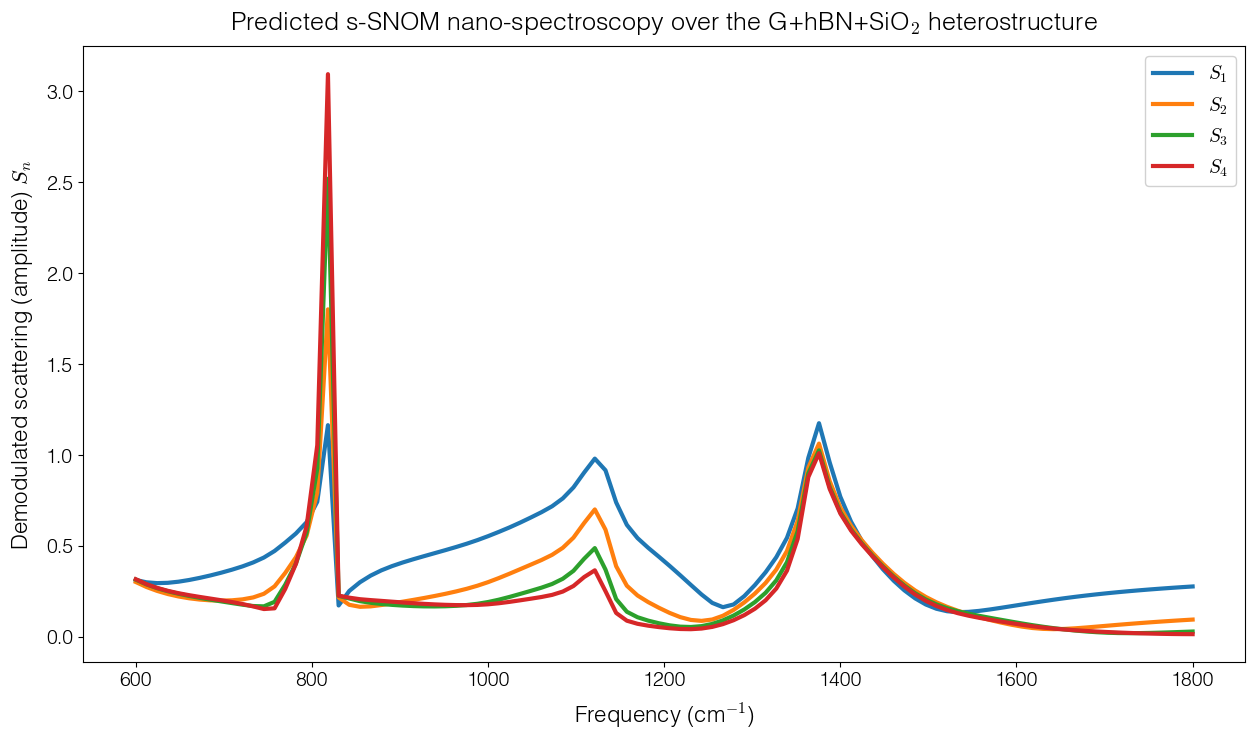

In [39]:
plt.figure(figsize=(15,8))
np.abs(S["Sn_norm"][1]).plot(label="$S_1$")
np.abs(S["Sn_norm"][2]).plot(label="$S_2$")
np.abs(S["Sn_norm"][3]).plot(label="$S_3$")
np.abs(S["Sn_norm"][4]).plot(label="$S_4$")
plt.legend();
plt.ylabel(r'Demodulated scattering (amplitude) $S_n$')
plt.title(r'Predicted s-SNOM nano-spectroscopy over the G+hBN+SiO$_2$ heterostructure')

Text(0, 0.5, 'Reflectivity  $|r_p(q^*,\\omega)|$')

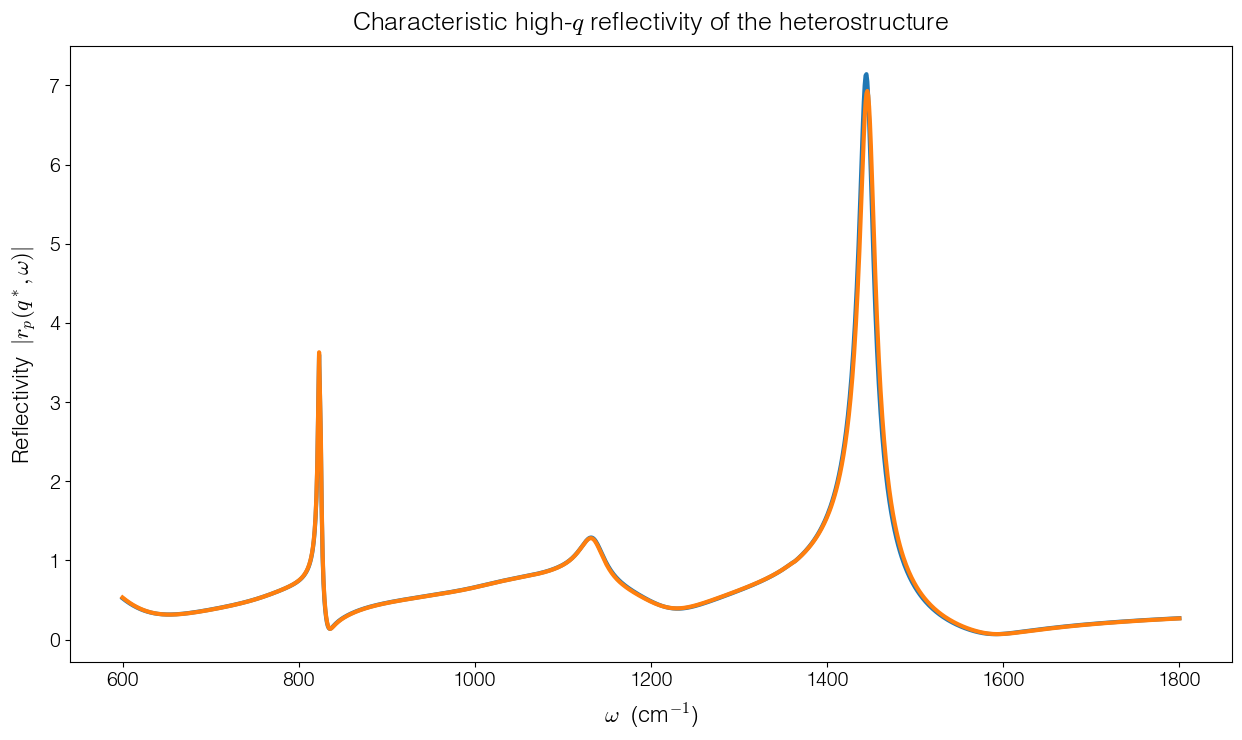

In [40]:
q_a = 1/(1e-7 * a_nm) # Inverse probe radius in 1/cm
qstar = q_a / 10 # momentum value typical of the evanescent electric fields emanated from the probe

plt.figure(figsize=(15,8))
np.abs(rp.cslice[:,qstar]).plot()
np.abs(rp.interpolate_axis(qstar,axis=1)).plot()
plt.title('Characteristic high-$q$ reflectivity of the heterostructure')
plt.ylabel(r'Reflectivity  $|r_p(q^*,\omega)|$')

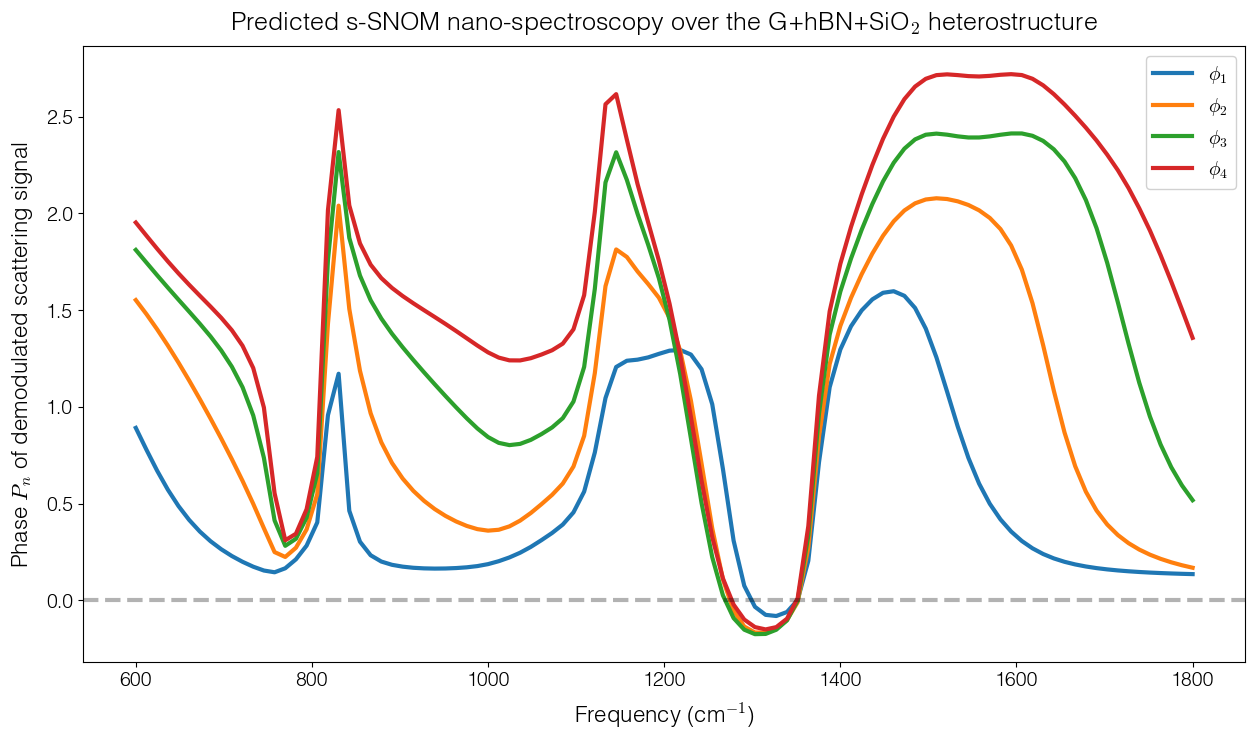

In [41]:
plt.figure(figsize=(15,8))
for n in np.arange(1,5):
    sn=S['Sn_norm'][n]
    pn=AWA(np.unwrap(np.arctan2(sn.imag,sn.real)),adopt_axes_from=sn)
    pn.plot(label=r'$\phi_%i$'%n)
plt.legend();
plt.ylabel(r'Phase $P_n$ of demodulated scattering signal')
plt.title(r'Predicted s-SNOM nano-spectroscopy over the G+hBN+SiO$_2$ heterostructure')
plt.axhline(0,ls='--',alpha=.3,color='k')

# Build your own isotropic material

In [42]:
#--- Build a phonon ---
w_TO = 600 # resonance frequency of the TO phonon, in cm^-1
amp_TO = 1 * w_TO**2 # This oscillator strength of the phonon physically corresponds with `w_LO**2-w_TO**2`
gamma_TO = 50 # Damping rate of the phonon, in cm^-1
eps_lps = [amp_TO,w_TO,gamma_TO] # put these all together as a set of "Lorentzian parameters" for one oscillator

#--- Build a plasma response (Drude) ---
wp = 2500 # unscreened plasma frequency, in cm^-1
gamma_drude = 300 # Scattering rate of the plasma, in cm^-1
drude_params = [wp,gamma_drude]

#--- Fix the high-energy permittivity
eps_infinity = 4
              
MyMetal = M.IsotropicMaterial(drude_params = drude_params,eps_infinity=eps_infinity,eps_lps = eps_lps)

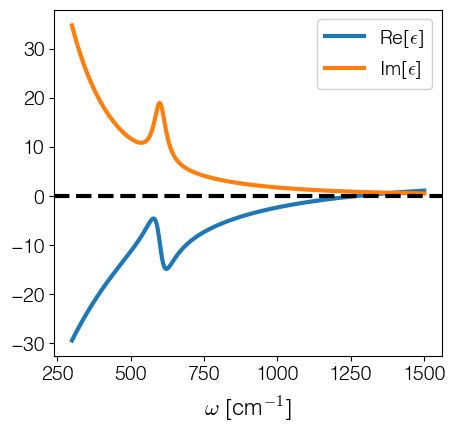

In [43]:
#--- Plot permittivity of your metal
ws = np.linspace(300,1500,1500)
eps = AWA(MyMetal.epsilon(ws),axes=[ws],axis_names=[r"$\omega$ [cm$^{-1}$]"])
eps.real.plot(label=r"Re[$\epsilon$]")
eps.imag.plot(label=r"Im[$\epsilon$]")
plt.legend();
plt.axhline(0,ls='--',color='k')

## Compute the reflectivity

Text(0.5, 1.0, 'Reflectivity from a custom metal')

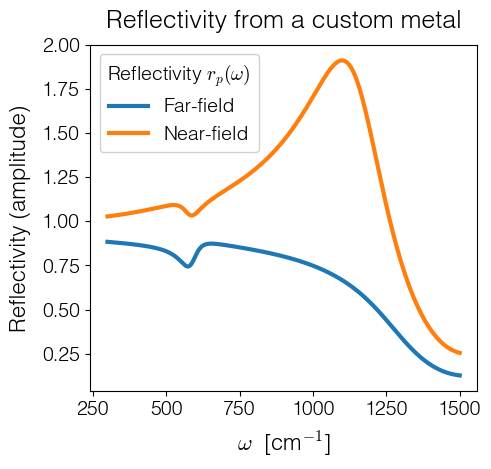

In [44]:
#--- Plot reflectivity of your metal, at q=0 (far-field), and at q=(10e-7 cm)^-1 (near-field)
Rp = MyMetal.reflection_p(ws,q=0)
rp = MyMetal.reflection_p(ws,q=1/10e-7)

np.abs(Rp).plot(label='Far-field')
np.abs(rp).plot(label='Near-field')
plt.legend(title=r'Reflectivity $r_p(\omega)$')
plt.xlabel(r"$\omega$  [cm$^{-1}$]")
plt.ylabel("Reflectivity (amplitude)")

plt.title('Reflectivity from a custom metal')

# Notice that the near-field reflectivity shows a plasmon peak where `epsilon=-1`
# The far-field reflectivity instead shows a plasma-edge at the same frequency

## Compute its near-field signal, where the material is bulk

In [45]:
a_nm = 20 # Physical dimension of probe radius, in nanometers
A_nm = 80 # Tapping amplitude, in nanometers
gapmin_nm = a_nm/10 # Physical dimension of minimum probe-sample distance, in nanometers
Ngaps = 12 # Number of probe-sample gap nodesto use for computing demodulated scattering
Nmodes=15 # Number of eigenmodes used for the prediction.

sim_kwargs = dict(amplitude_nm=A_nm,gapmin_nm = gapmin_nm,a_nm=a_nm,Ngaps=Ngaps,Nmodes=Nmodes)

freqs_wn = np.linspace(300,1500,100)
norm_to = M.Au # Normalize to gold

S = EE.getNormalizedSignal(freqs_wn,
                           rp=MyMetal.reflection_p,
                           rp_norm = norm_to.reflection_p,
                           norm_single_freq=True,
                           **sim_kwargs)

	Computing at freq=3.000E+02...
	Computing at freq=3.122E+02...
	Computing at freq=3.243E+02...
	Computing at freq=3.364E+02...
	Computing at freq=3.485E+02...
	Computing at freq=3.607E+02...
	Computing at freq=3.728E+02...
	Computing at freq=3.849E+02...
	Computing at freq=3.970E+02...
	Computing at freq=4.091E+02...
	Computing at freq=4.213E+02...
	Computing at freq=4.334E+02...
	Computing at freq=4.455E+02...
	Computing at freq=4.576E+02...
	Computing at freq=4.698E+02...
	Computing at freq=4.819E+02...
	Computing at freq=4.940E+02...
	Computing at freq=5.061E+02...
	Computing at freq=5.182E+02...
	Computing at freq=5.304E+02...
	Computing at freq=5.425E+02...
	Computing at freq=5.546E+02...
	Computing at freq=5.667E+02...
	Computing at freq=5.789E+02...
	Computing at freq=5.910E+02...
	Computing at freq=6.031E+02...
	Computing at freq=6.152E+02...
	Computing at freq=6.274E+02...
	Computing at freq=6.395E+02...
	Computing at freq=6.516E+02...
	Computing at freq=6.637E+02...
	Computi

Text(0.5, 1.0, 'Predicted s-SNOM nano-spectroscopy over the custom metal')

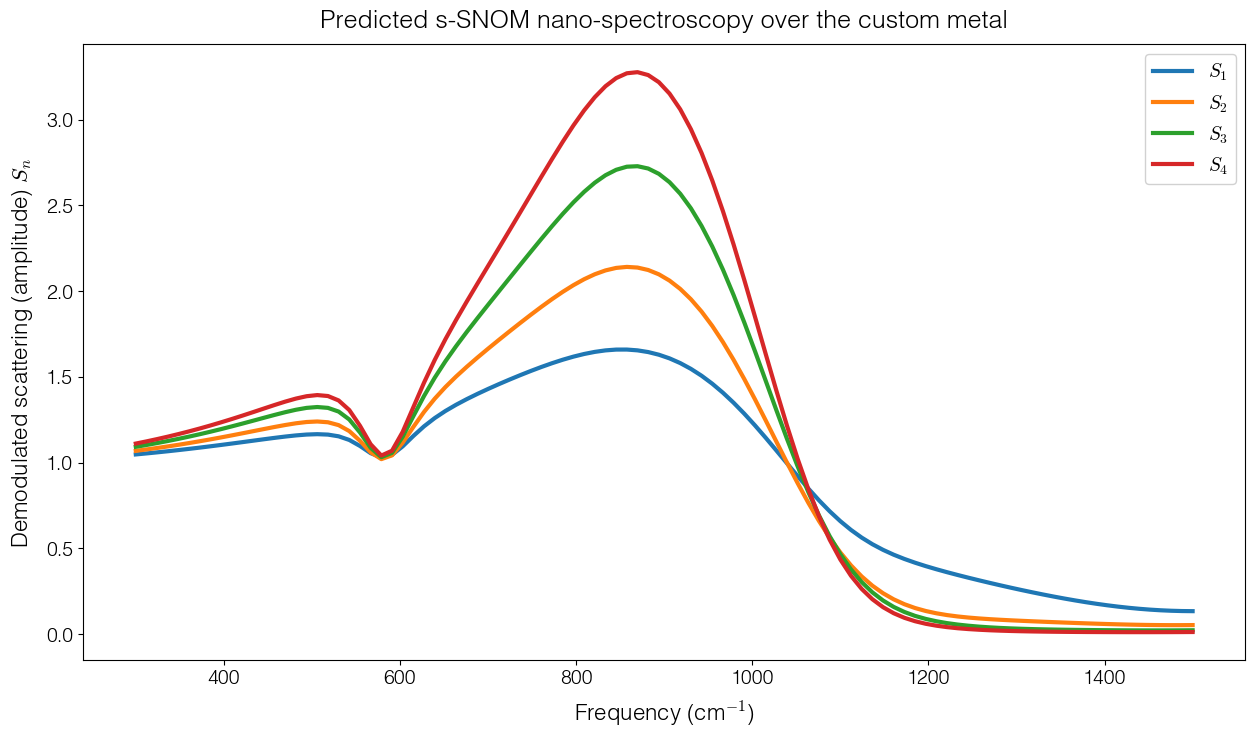

In [46]:
plt.figure(figsize=(15,8))
np.abs(S["Sn_norm"][1]).plot(label="$S_1$")
np.abs(S["Sn_norm"][2]).plot(label="$S_2$")
np.abs(S["Sn_norm"][3]).plot(label="$S_3$")
np.abs(S["Sn_norm"][4]).plot(label="$S_4$")
plt.legend();
plt.legend();
plt.ylabel(r'Demodulated scattering (amplitude) $S_n$')
plt.title(r'Predicted s-SNOM nano-spectroscopy over the custom metal')

## Compute its near-field signal, where the material is a thin film sitting on top of SiO2

In [47]:
thickness = 40e-7 # Thickness of your material, in cm (this one is 100 nm thick)
MyLayers = M.LayeredMediaTM((MyMetal,thickness), exit= M.SiO2_300nm)

Text(0.5, 1.0, 'Reflectivity Im[$r_p(q,\\omega)$] of the custom metal')

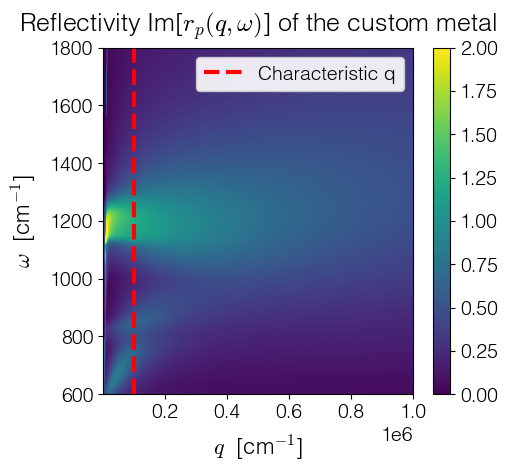

In [48]:
#--- Might as well compute the rp-dispersion of this heterotructure!  It should have a dispersing plasmon.
ws = np.linspace(600,1800,1200)
q0=1/10e-7
qs = np.linspace(1e-3*q0, 1*q0, 500)
rp = MyLayers.reflection_p(ws,qs)
axis_names = [r"$\omega$  [cm$^{-1}$]", r'$q$  [cm$^{-1}$]']
rp.set_axes(axis_names=axis_names)

f=plt.figure()
rp.imag.T.plot()
plt.clim(0,2)
plt.sca(f.axes[0])
plt.axvline(q0/10,color='r',ls='--',label='Characteristic q')
plt.legend()

plt.title(r'Reflectivity Im[$r_p(q,\omega)$] of the custom metal')

In [49]:
a_nm = 20 # Physical dimension of probe radius, in nanometers
A_nm = 80 # Tapping amplitude, in nanometers
gapmin_nm = a_nm/10 # Physical dimension of minimum probe-sample distance, in nanometers
Ngaps = 12 # Number of probe-sample gap nodesto use for computing demodulated scattering
Nmodes=15 # Number of eigenmodes used for the prediction.

sim_kwargs = dict(amplitude_nm=A_nm,gapmin_nm = gapmin_nm,a_nm=a_nm,Ngaps=Ngaps,Nmodes=Nmodes)

ws = np.linspace(600,1800,100)
norm_to = M.Au # Normalize to gold

S = EE.getNormalizedSignal(freqs_wn,
                           rp=MyLayers.reflection_p,
                           rp_norm = norm_to.reflection_p,
                           norm_single_freq=True,
                           **sim_kwargs)

	Computing at freq=3.000E+02...
	Computing at freq=3.122E+02...
	Computing at freq=3.243E+02...
	Computing at freq=3.364E+02...
	Computing at freq=3.485E+02...
	Computing at freq=3.607E+02...
	Computing at freq=3.728E+02...
	Computing at freq=3.849E+02...
	Computing at freq=3.970E+02...
	Computing at freq=4.091E+02...
	Computing at freq=4.213E+02...
	Computing at freq=4.334E+02...
	Computing at freq=4.455E+02...
	Computing at freq=4.576E+02...
	Computing at freq=4.698E+02...
	Computing at freq=4.819E+02...
	Computing at freq=4.940E+02...
	Computing at freq=5.061E+02...
	Computing at freq=5.182E+02...
	Computing at freq=5.304E+02...
	Computing at freq=5.425E+02...
	Computing at freq=5.546E+02...
	Computing at freq=5.667E+02...
	Computing at freq=5.789E+02...
	Computing at freq=5.910E+02...
	Computing at freq=6.031E+02...
	Computing at freq=6.152E+02...
	Computing at freq=6.274E+02...
	Computing at freq=6.395E+02...
	Computing at freq=6.516E+02...
	Computing at freq=6.637E+02...
	Computi

Text(0.5, 1.0, 'Predicted s-SNOM nano-spectroscopy over the custom metal-on-SiO$_2$ heterostructure')

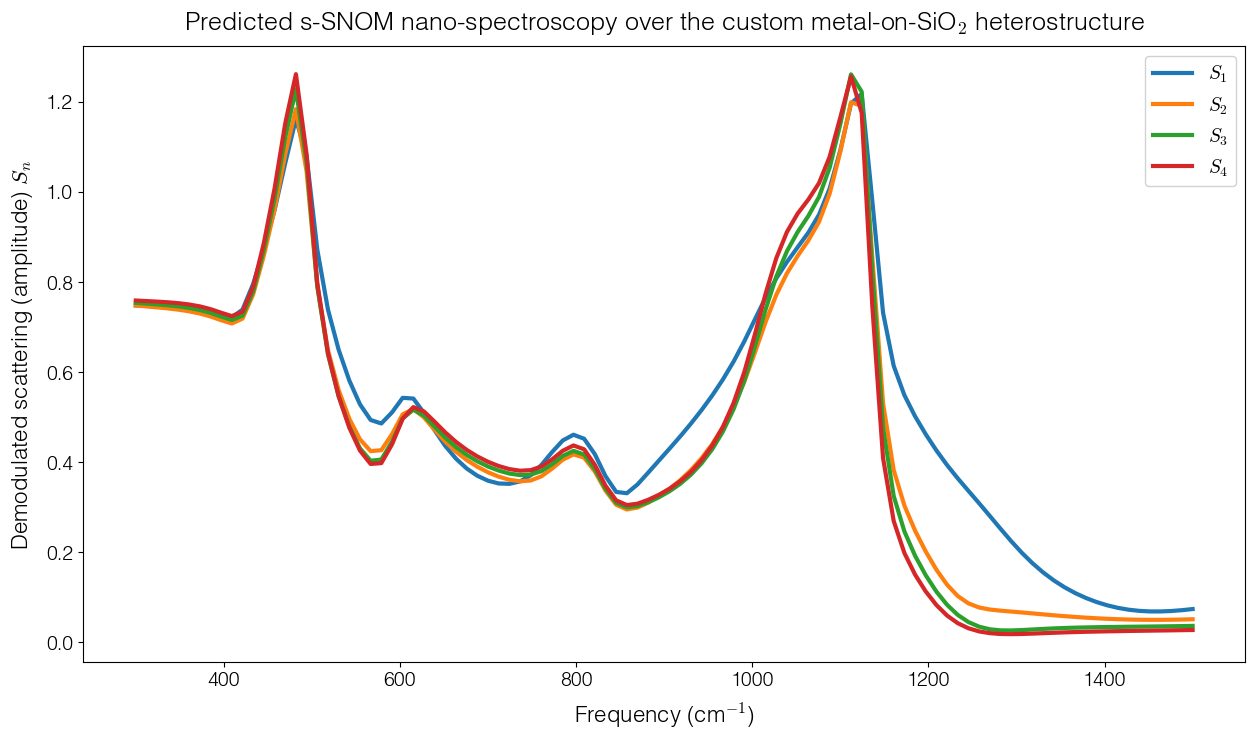

In [50]:
plt.figure(figsize=(15,8))
np.abs(S["Sn_norm"][1]).plot(label="$S_1$")
np.abs(S["Sn_norm"][2]).plot(label="$S_2$")
np.abs(S["Sn_norm"][3]).plot(label="$S_3$")
np.abs(S["Sn_norm"][4]).plot(label="$S_4$")
plt.legend();
plt.legend();
plt.ylabel(r'Demodulated scattering (amplitude) $S_n$')
plt.title(r'Predicted s-SNOM nano-spectroscopy over the custom metal-on-SiO$_2$ heterostructure')

#--- We should see several peaks:
# - the SiO2 (substrate) phonons at 500 cm-1, 800 cm-1 (weak), and 1100 cm-1
# - The layer phonon at 600 cm-1
# - The layer plasmon spanning 0-1000 cm-1.  